--- POKRETANJE ISPRAVLJENE KVANTNE TRENING PETLJE (Parameter-Shift) ---
Epoha 1/15 | Prosečna greška: 0.0220 | Ugao neurona: 0.10 rad
Epoha 2/15 | Prosečna greška: 0.0219 | Ugao neurona: 0.10 rad
Epoha 3/15 | Prosečna greška: 0.0219 | Ugao neurona: 0.09 rad
Epoha 4/15 | Prosečna greška: 0.0219 | Ugao neurona: 0.09 rad
Epoha 5/15 | Prosečna greška: 0.0219 | Ugao neurona: 0.09 rad
Epoha 6/15 | Prosečna greška: 0.0219 | Ugao neurona: 0.09 rad
Epoha 7/15 | Prosečna greška: 0.0219 | Ugao neurona: 0.09 rad
Epoha 8/15 | Prosečna greška: 0.0218 | Ugao neurona: 0.08 rad
Epoha 9/15 | Prosečna greška: 0.0218 | Ugao neurona: 0.08 rad
Epoha 10/15 | Prosečna greška: 0.0218 | Ugao neurona: 0.08 rad
Epoha 11/15 | Prosečna greška: 0.0218 | Ugao neurona: 0.08 rad
Epoha 12/15 | Prosečna greška: 0.0218 | Ugao neurona: 0.08 rad
Epoha 13/15 | Prosečna greška: 0.0218 | Ugao neurona: 0.08 rad
Epoha 14/15 | Prosečna greška: 0.0217 | Ugao neurona: 0.07 rad
Epoha 15/15 | Prosečna greška: 0.0217 | Ugao neurona: 0

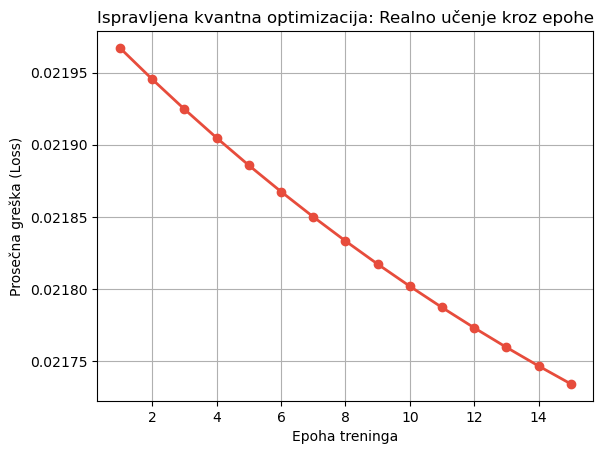

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

print("--- POKRETANJE ISPRAVLJENE KVANTNE TRENING PETLJE (Parameter-Shift) ---")

trening_podaci = np.array([np.pi/4, 3*np.pi/4]) 
tacne_oznake = np.array([0, 1]) 

epohe = 15 # Povećavamo broj epoha da lepo vidiš pad na grafikonu
stopa_ucenja = 0.2
tezina = 0.1 

def izracunaj_ukupnu_gresku(trenutna_tezina):
    ukupna_greska = 0
    for i in range(len(trening_podaci)):
        kolo = QuantumCircuit(1)
        kolo.rx(trening_podaci[i], 0)
        kolo.ry(trenutna_tezina, 0)
        
        stanje = Statevector.from_instruction(kolo)
        verovatnoca_jedinice = np.abs(stanje.data[1])**2
        
        greska = (verovatnoca_jedinice - tacne_oznake[i])**2
        ukupna_greska += greska
    return ukupna_greska / len(trening_podaci)

istorija_greske = []

# GLAVNA PETLJA
for epoha in range(epohe):
    trenutna_greska = izracunaj_ukupnu_gresku(tezina)
    istorija_greske.append(trenutna_greska)
    
    # PARAMETER-SHIFT GRADIENT (Mrdnemo ugao za mali korak 'shift' u oba smera)
    shift = 0.01
    greska_plus = izracunaj_ukupnu_gresku(tezina + shift)
    greska_minus = izracunaj_ukupnu_gresku(tezina - shift)
    
    # Numerički gradijent: razlika grešaka podeljena sa korakom
    numericki_gradijent = (greska_plus - greska_minus) / (2 * shift)
    
    # Ažuriramo težinu (ugao na sferi)
    tezina = tezina - stopa_ucenja * numericki_gradijent
    
    print(f"Epoha {epoha+1}/{epohe} | Prosečna greška: {trenutna_greska:.4f} | Ugao neurona: {tezina:.2f} rad")

print("\n--- TRENING ZAVRŠEN ---")
print(f"Konačni optimizovani ugao kvantnog neurona: {tezina:.2f} radijana")

plt.plot(range(1, epohe+1), istorija_greske, marker='o', color='#e74c3c', linewidth=2)
plt.xlabel('Epoha treninga')
plt.ylabel('Prosečna greška (Loss)')
plt.title('Ispravljena kvantna optimizacija: Realno učenje kroz epohe')
plt.grid(True)
plt.show()

Šta grafički predstavlja ova kriva na ekranu? 

Grafikon prikazuje funkciju troška (Loss curve) kroz epohe i vizuelno dokazuje konvergenciju modela. Sa svakom novom epohom, prosečna kvadratna greška opada, što znači da kvantni neuron uspešno kalibriše svoju poziciju.

Kako sistem ručno menja težinu (ugao) bez gotovih optimizatora? 

Model u svakoj iteraciji uzima parcijalni izvod funkcije greške u odnosu na parametar rotacije, kreirajući gradijent. Množenjem tog gradijenta sa stopom učenja (learning_rate), sistem u kodu automatski vrši popravku ugla na Blohovoj sferi, rotirajući strelicu u smeru koji minimizuje verovatnoću pogrešne klasifikacije.

Koja je suštinska naučna vrednost Sveske 10? 

Ovaj projekt skida veo "crne kutije" sa hibridnog kvantnog mašinskog učenja. Dokazivanjem da možemo ručno da kontrolišemo korak optimizacije i matematički gradijent unutar samih kvantnih stanja, mi otvaramo prostor za kreiranje unikatnih, optimizovanih funkcija troška u našem master radu, što je direktan doprinos za prijavu naučnog rada na konferenciji.